In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [5]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [67]:
df.shape

(299, 13)

In [7]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [15]:
df["DEATH_EVENT"].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [69]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [71]:
X = df.drop(columns="DEATH_EVENT",axis=1)
y = df["DEATH_EVENT"]

In [73]:
X.shape , y.shape

((299, 12), (299,))

In [163]:
def outlier(X):
    # Loop through each column in the DataFrame
    for column in X.columns:
        if np.issubdtype(X[column].dtype, np.number):  # Check if the column is numeric
            plt.figure(figsize=(7, 4))
            
            # KDE plot
            sns.boxplot(X[column])
            plt.title(f"boxplot Plot for {column}", fontsize=14)
        
            # plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

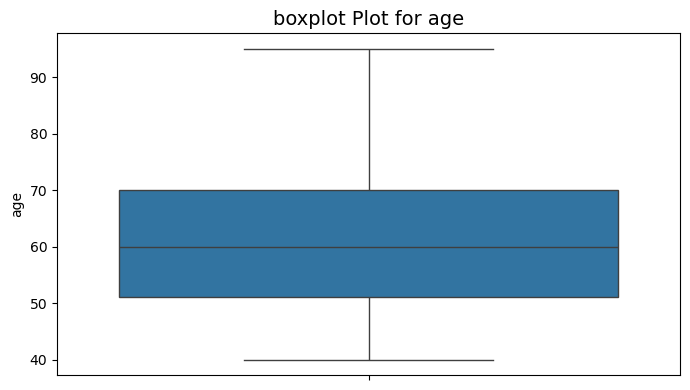

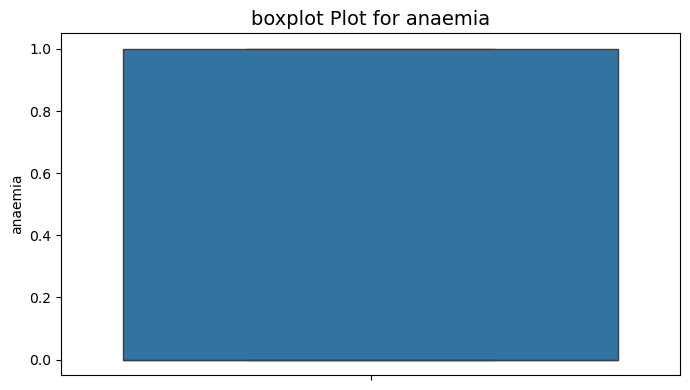

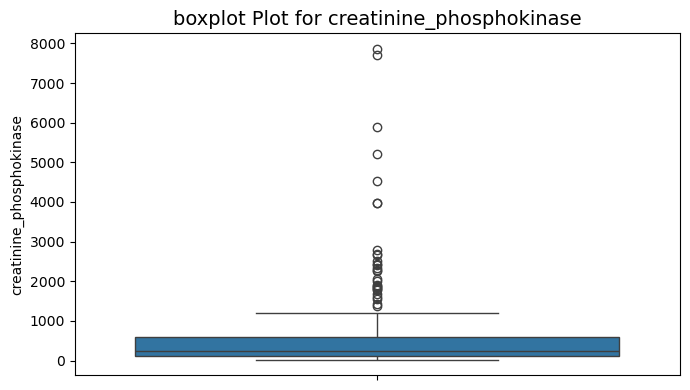

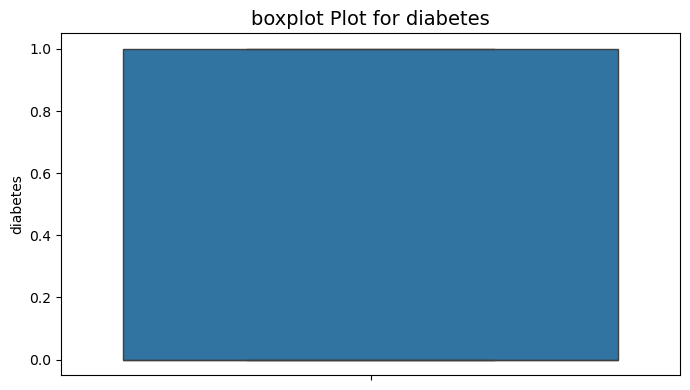

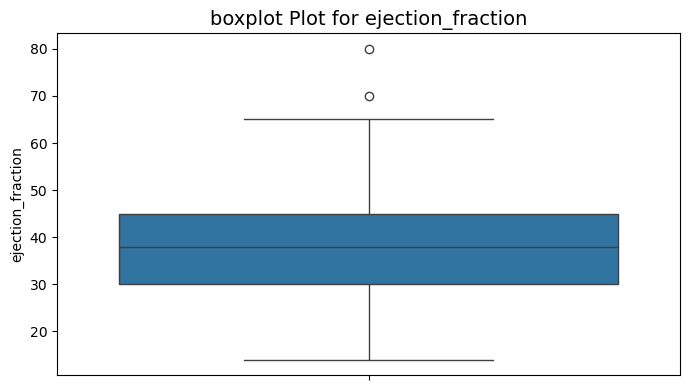

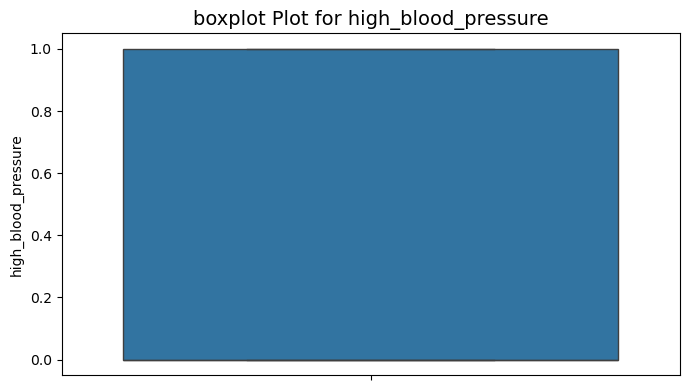

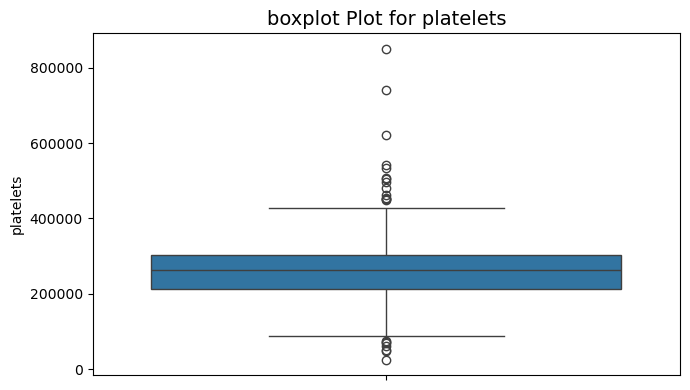

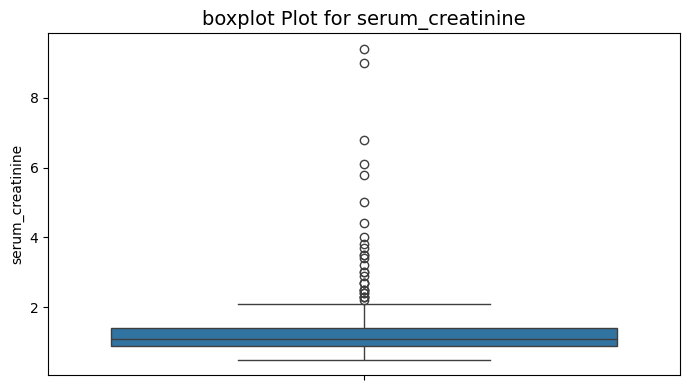

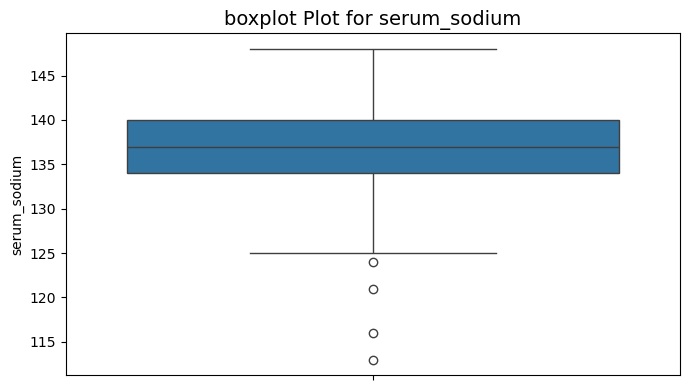

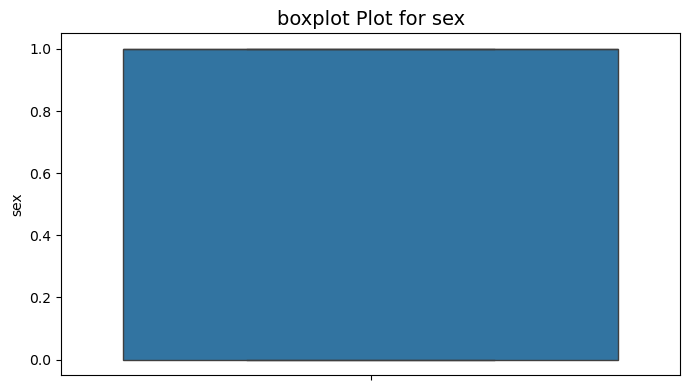

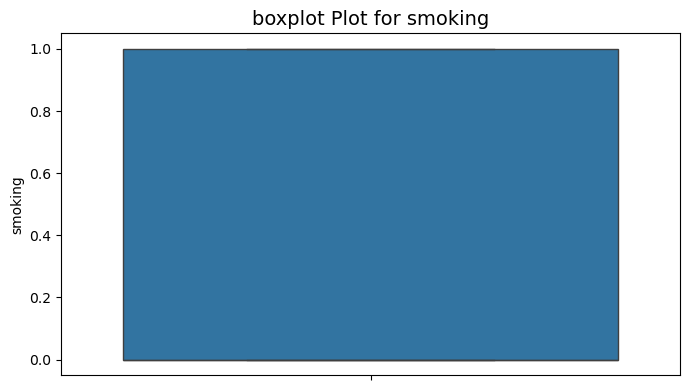

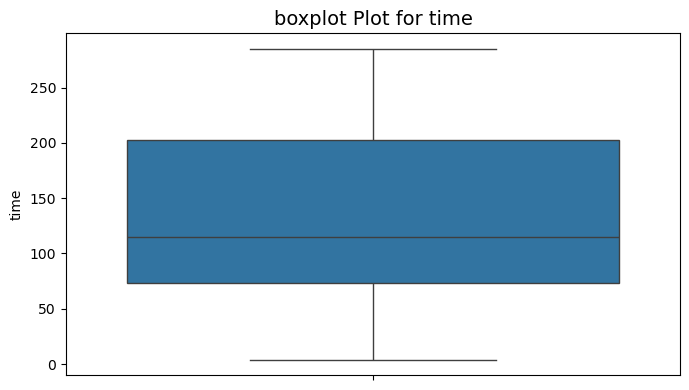

In [165]:
outlier(X)

In [167]:
# Function to cap outliers using IQR
def cap_outliers_iqr(df):
    df_capped = df.copy()  # Make a copy to avoid modifying the original DataFrame

    # Loop through numeric columns and cap outliers based on IQR
    for column in df_capped.select_dtypes(include=[np.number]).columns:
        Q1 = df_capped[column].quantile(0.25)
        Q3 = df_capped[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap values outside the bounds to the lower or upper bound
        df_capped[column] = np.clip(df_capped[column], lower_bound, upper_bound)

    return df_capped

In [169]:
X_new = cap_outliers_iqr(X)

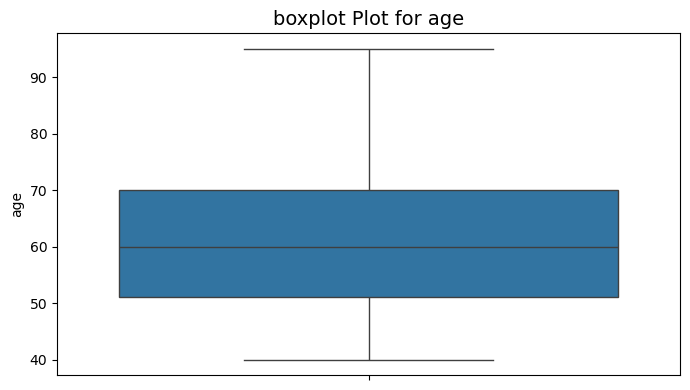

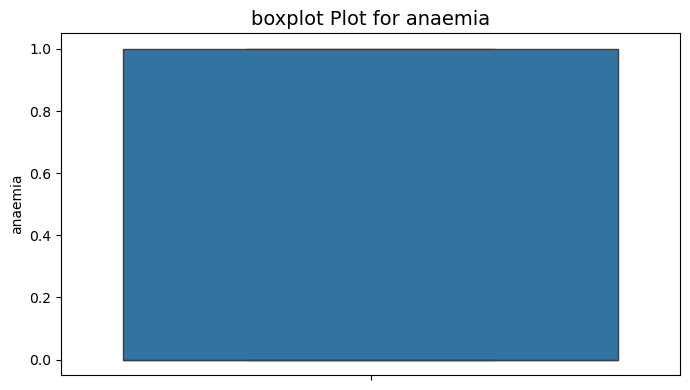

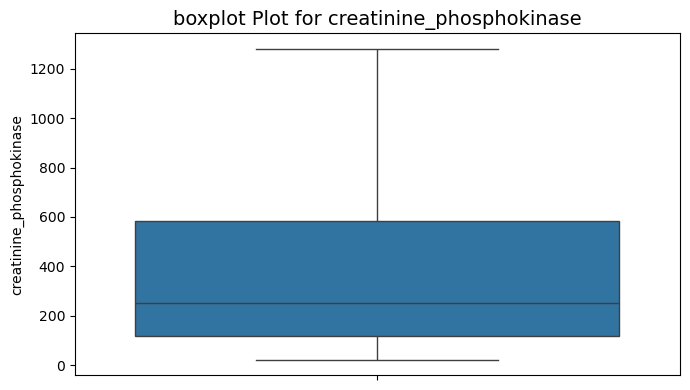

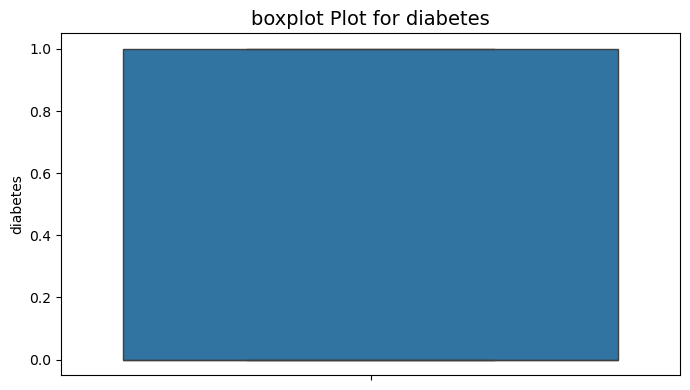

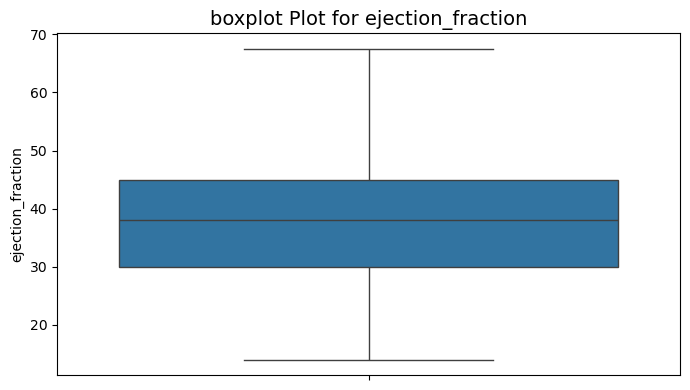

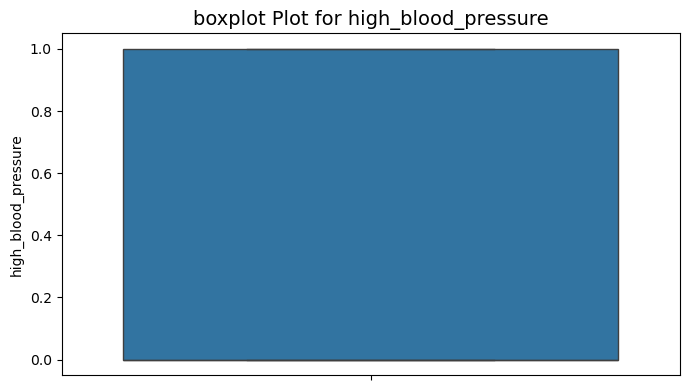

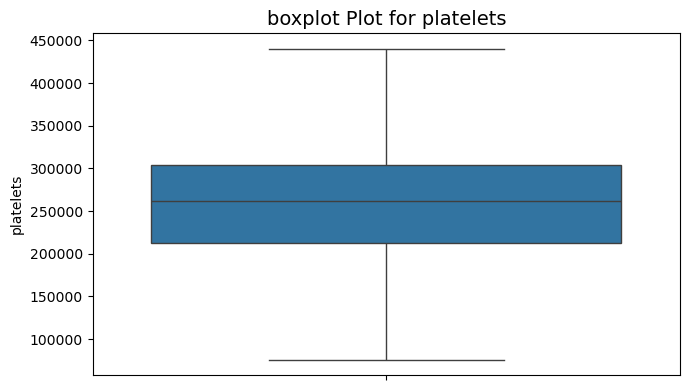

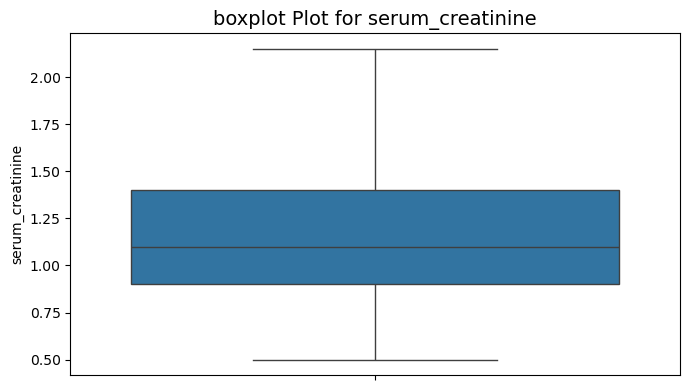

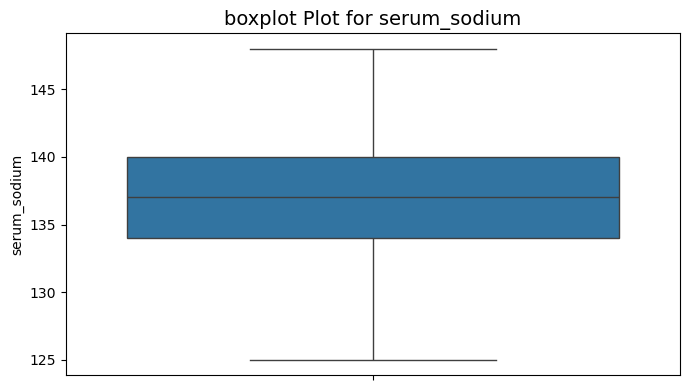

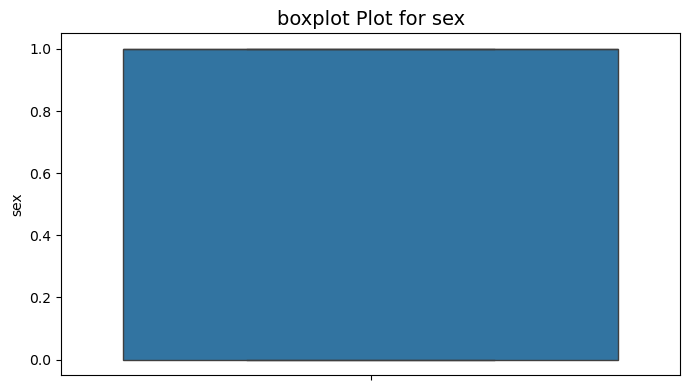

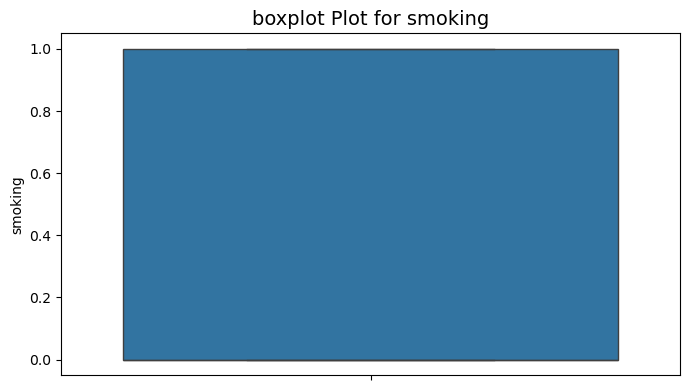

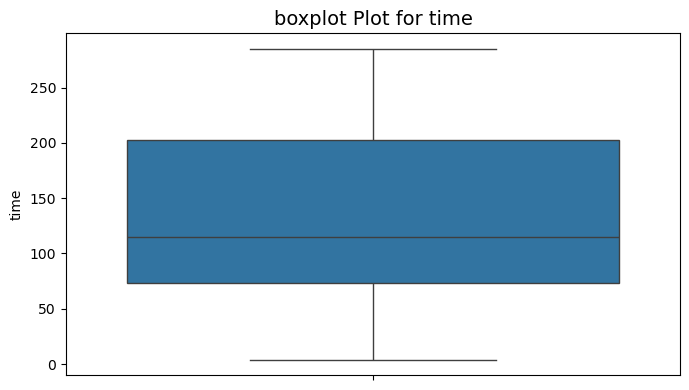

In [171]:
outlier(X_new)

In [172]:
def All_plot(X):
    col = X.columns
    for column in col:
        if np.issubdtype(X[column].dtype, np.number):  # Check if the column is numeric
            fig, axes = plt.subplots(1, 3, figsize=(21, 6))  # 3 plots in a row
            
            skewness = X[column].skew()
            
            # Determine skewness type
            if skewness > 0:
                skew_type = "Positive Skewness"
            elif skewness < 0:
                skew_type = "Negative Skewness"
            else:
                skew_type = "Approximately Symmetrical"
            
            print(f"{column}: Skewness = {skewness:.2f} ({skew_type})")
            
            # KDE plot
            sns.kdeplot(X[column].dropna(), fill=True, color='blue', alpha=0.5, ax=axes[0])
            axes[0].set_title(f"KDE Plot for {column}\n(Skewness: {skewness:.2f}) ({skew_type})", fontsize=12)
            axes[0].set_xlabel(column)
            axes[0].set_ylabel('Density')
            axes[0].grid(alpha=0.3)
        
            # Q-Q plot
            stats.probplot(X[column].dropna(), dist="norm", plot=axes[1])
            axes[1].set_title(f"Q-Q Plot for {column}", fontsize=12)
            
            # Boxplot
            sns.boxplot(x=X[column], ax=axes[2])
            axes[2].set_title(f"Boxplot for {column}", fontsize=12)
            axes[2].set_xlabel(column)
            
            plt.tight_layout()
            plt.show()

age: Skewness = 0.42 (Positive Skewness)


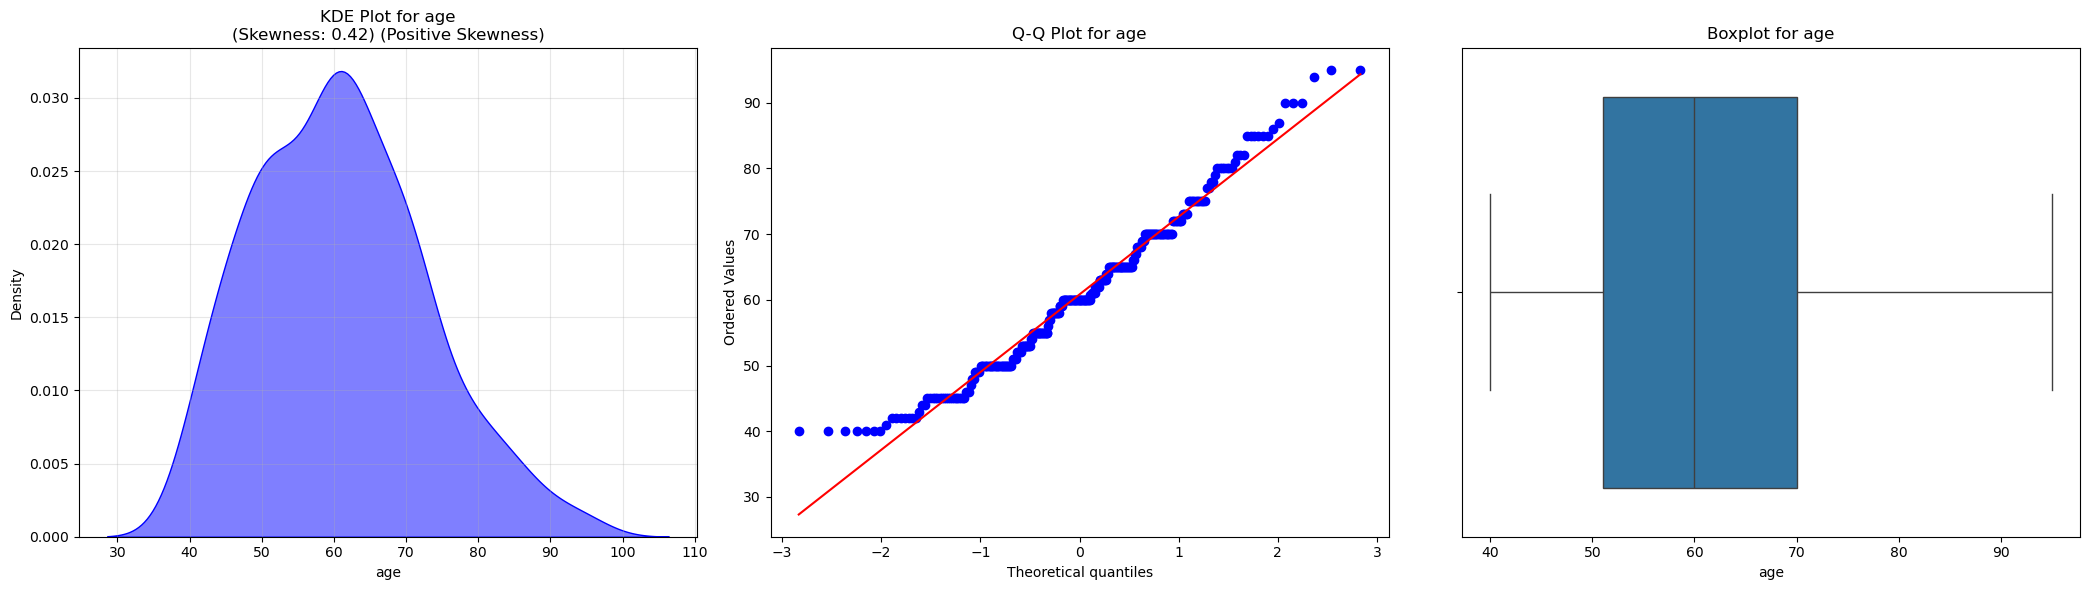

anaemia: Skewness = 0.28 (Positive Skewness)


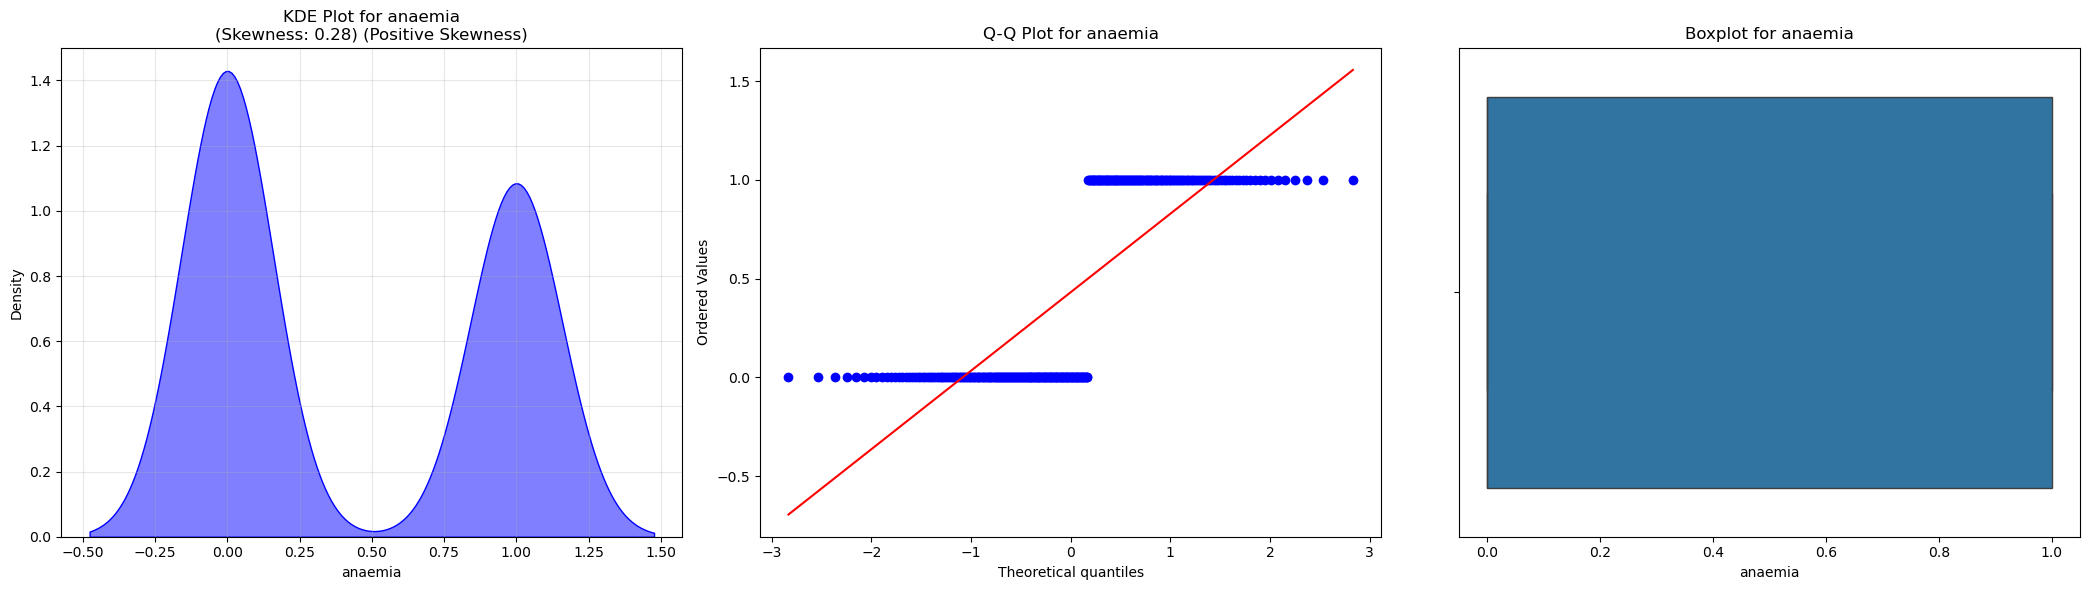

creatinine_phosphokinase: Skewness = 1.07 (Positive Skewness)


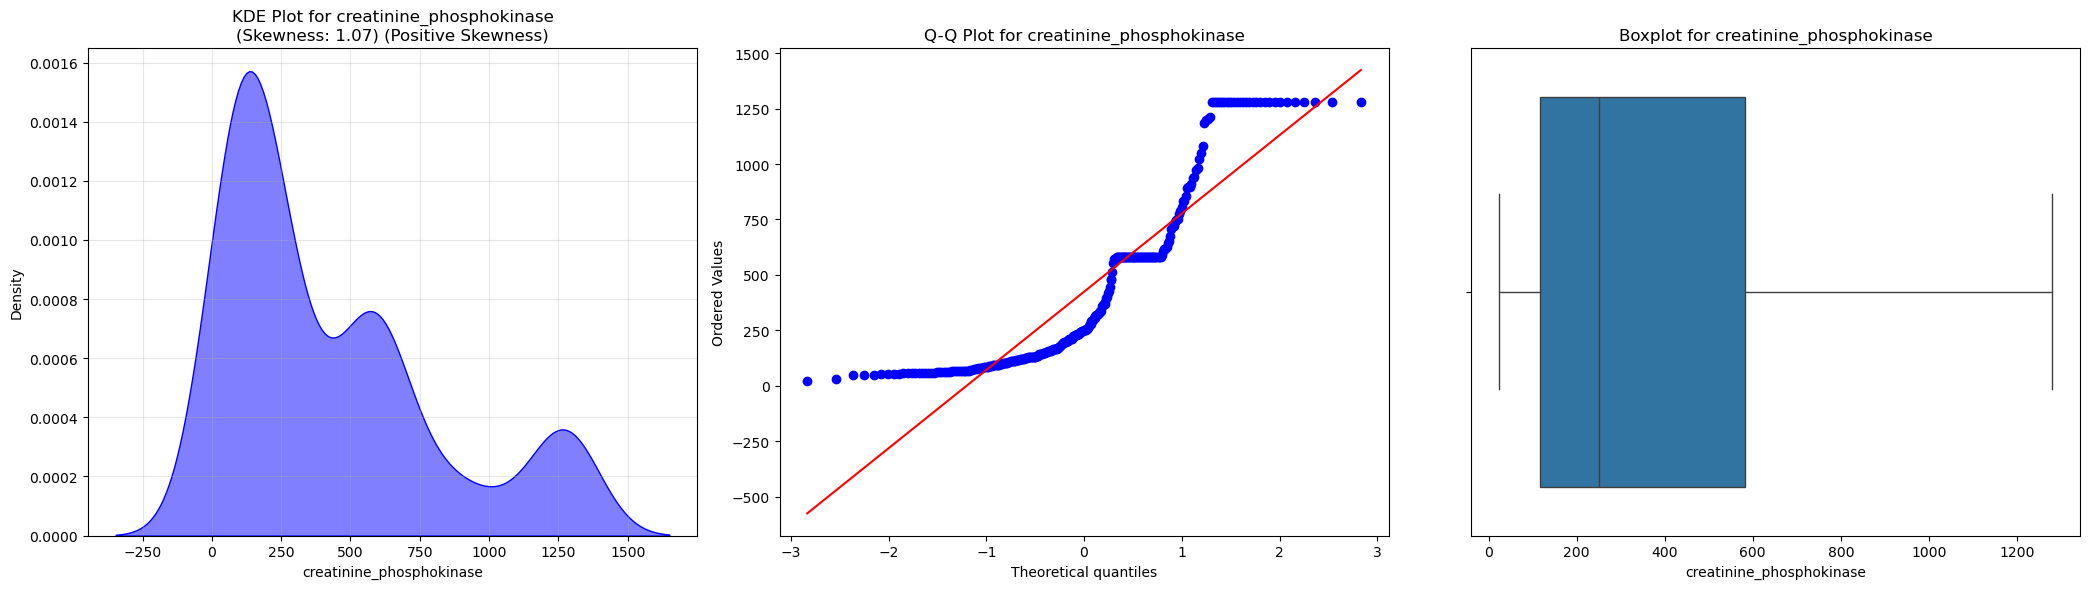

diabetes: Skewness = 0.33 (Positive Skewness)


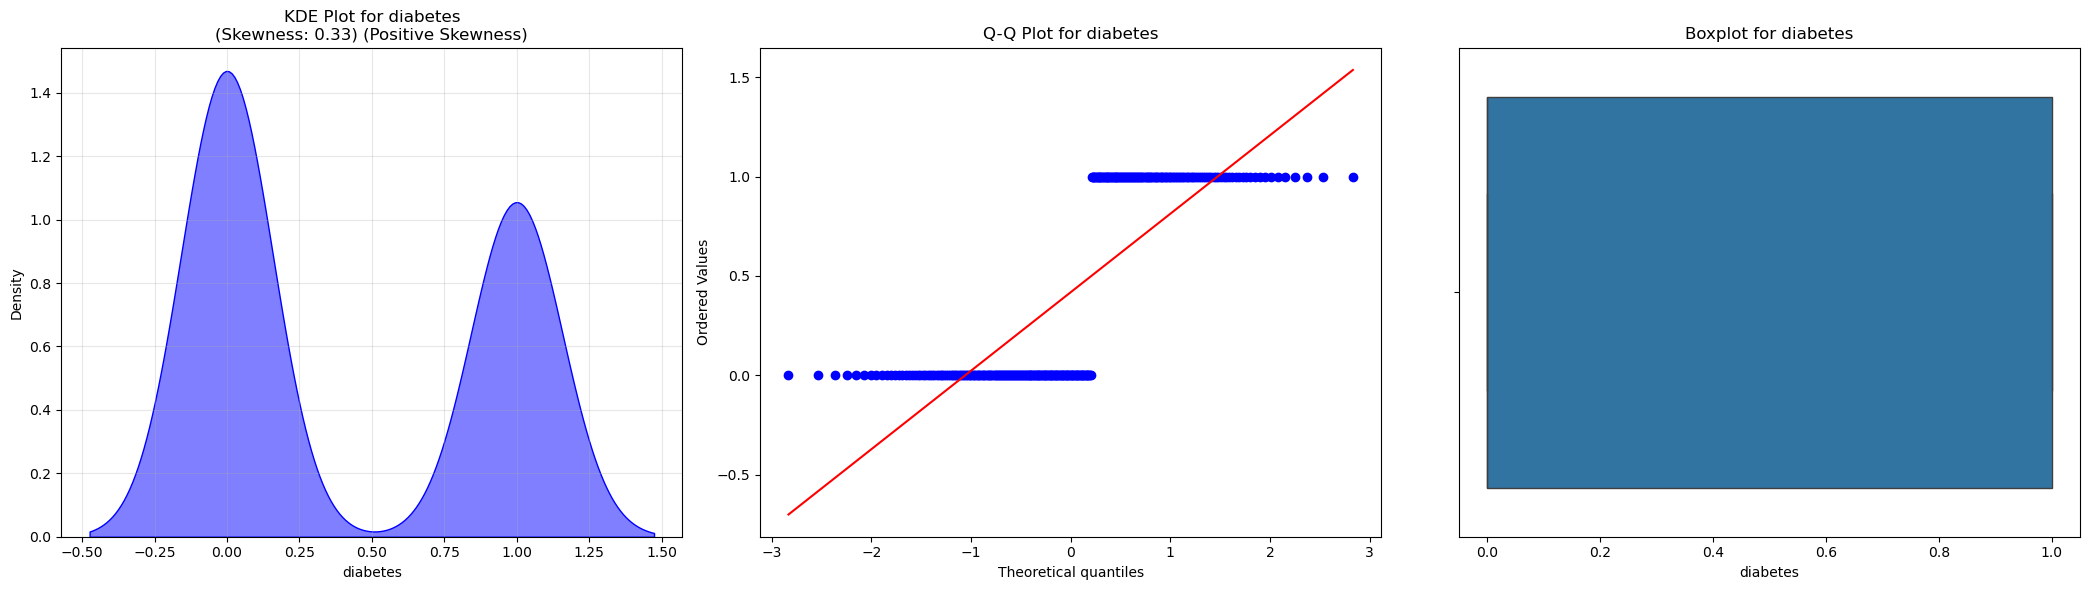

ejection_fraction: Skewness = 0.47 (Positive Skewness)


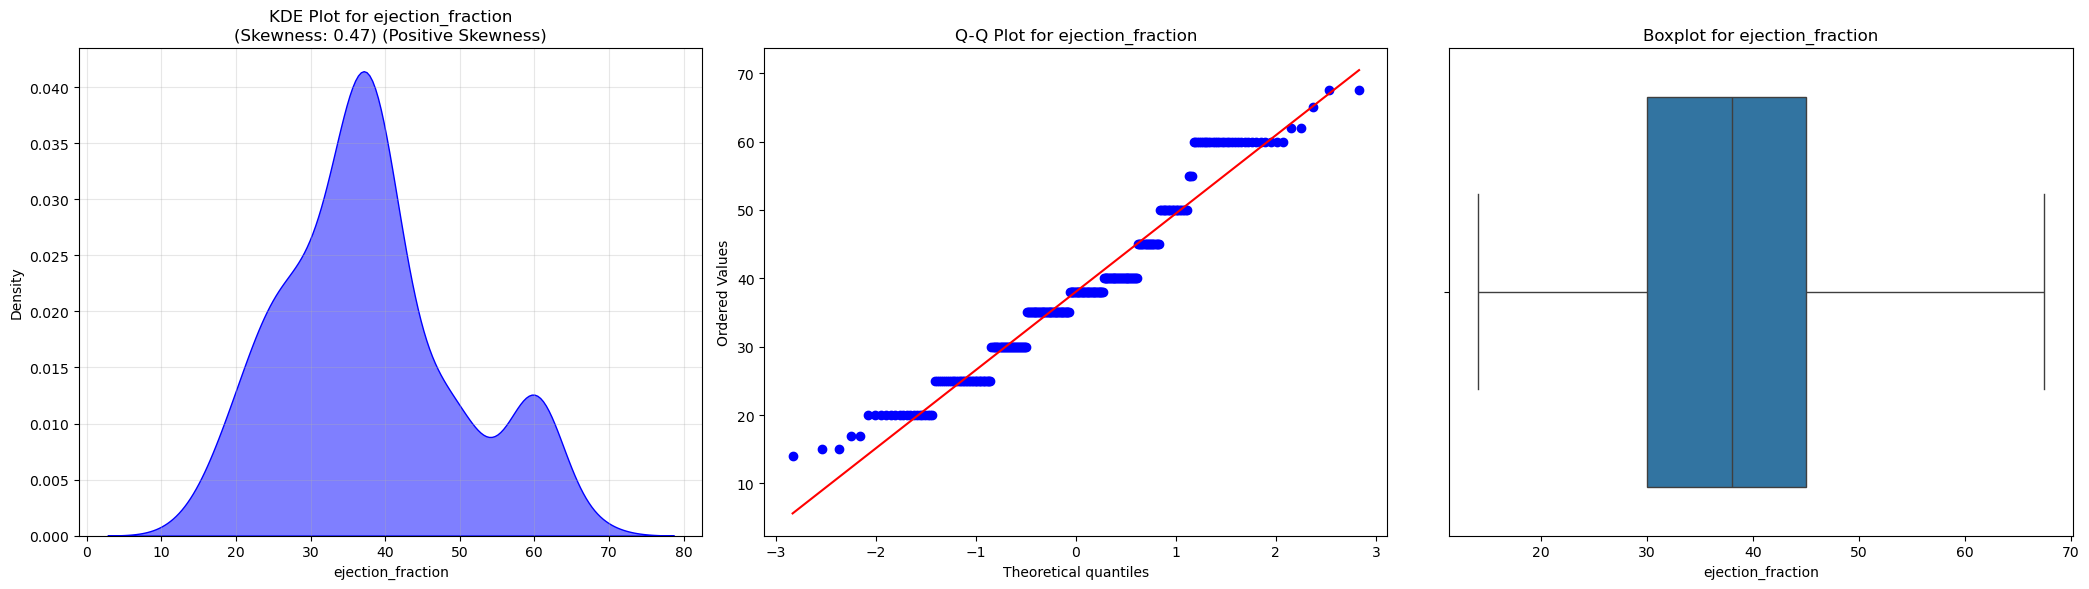

high_blood_pressure: Skewness = 0.63 (Positive Skewness)


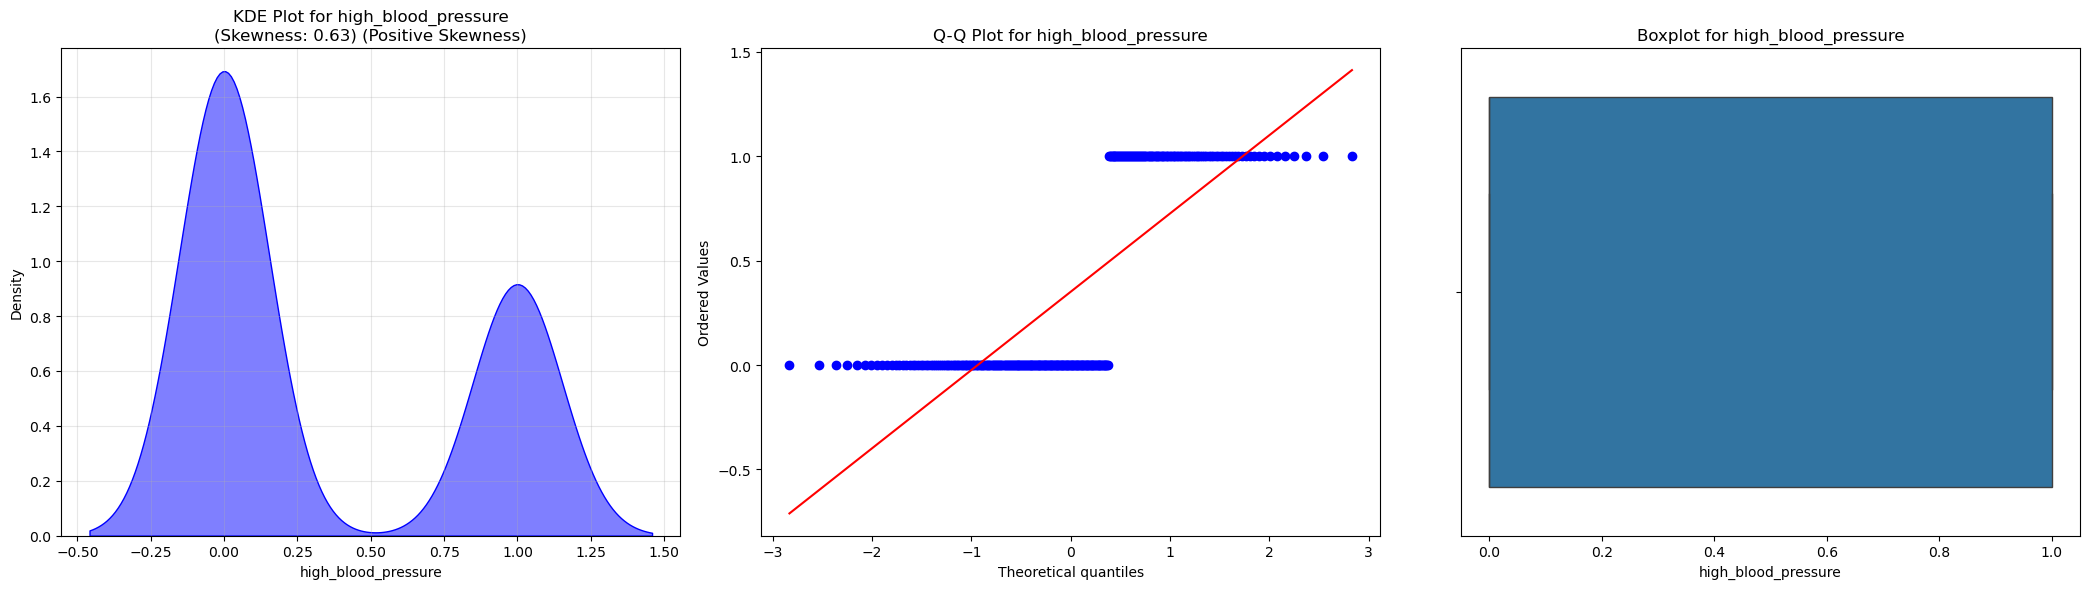

platelets: Skewness = 0.24 (Positive Skewness)


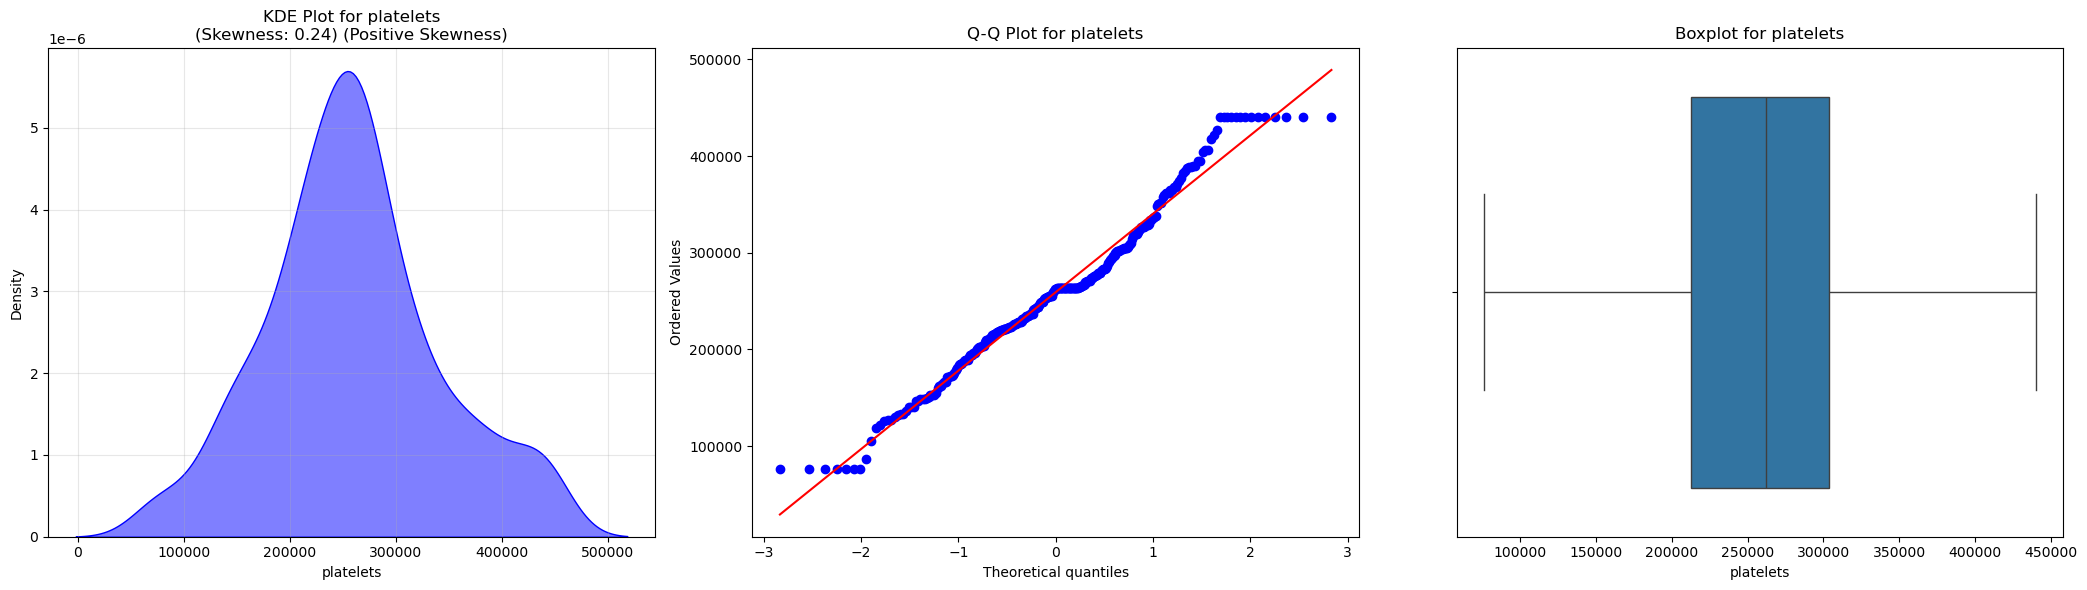

serum_creatinine: Skewness = 0.91 (Positive Skewness)


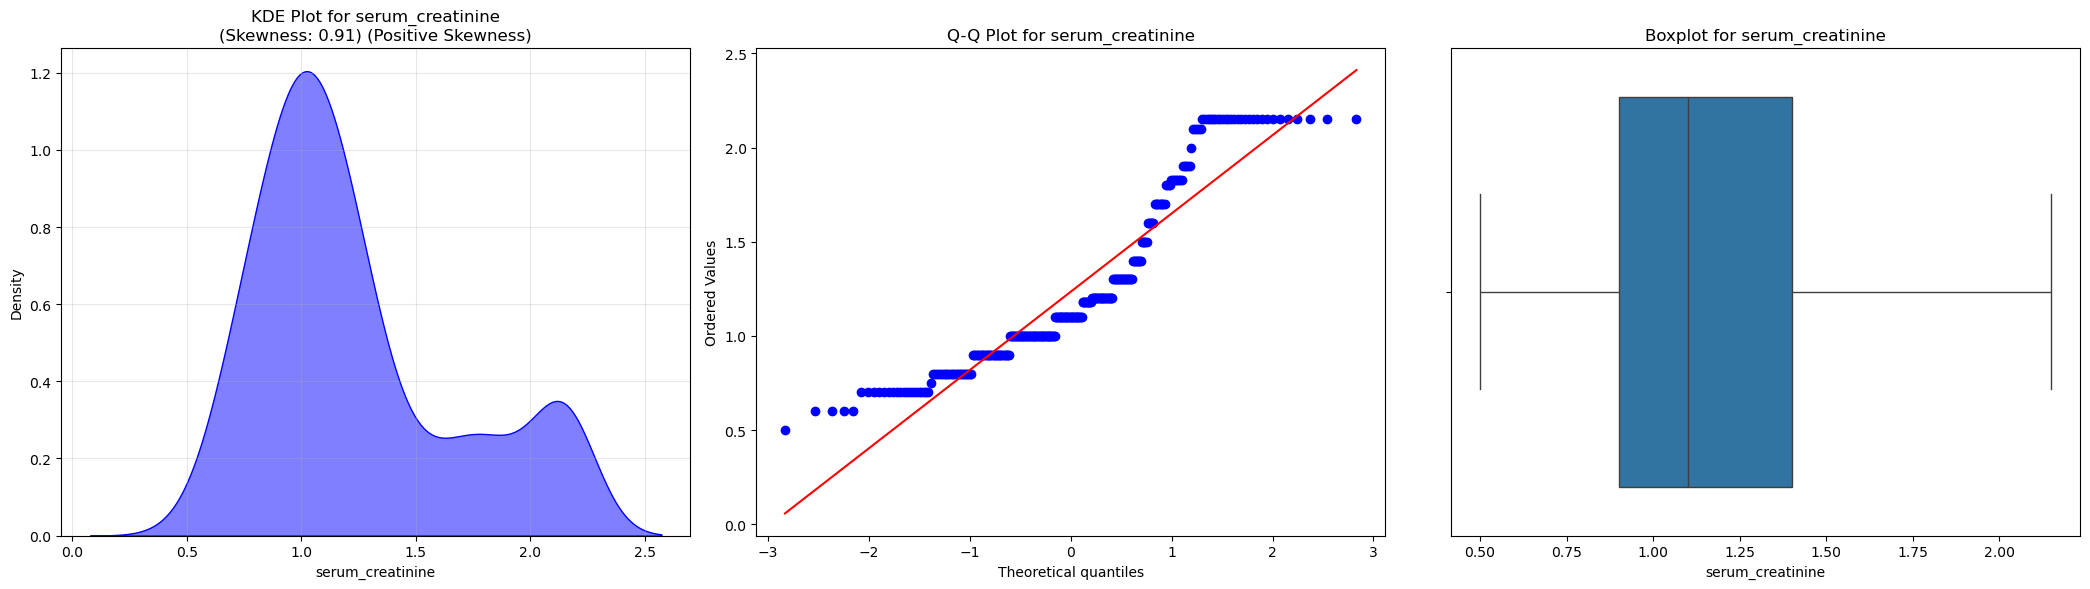

serum_sodium: Skewness = -0.32 (Negative Skewness)


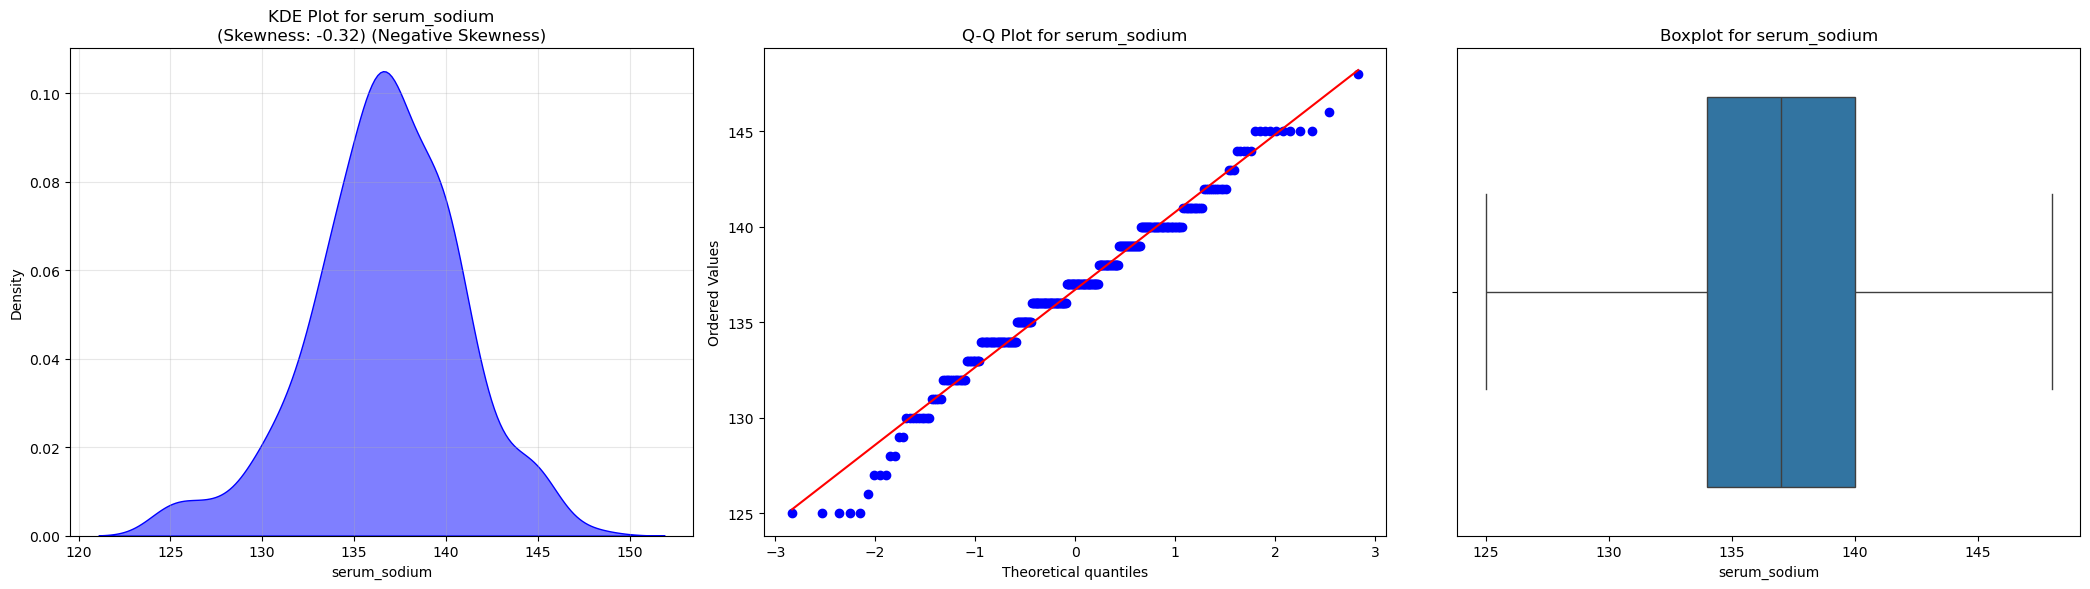

sex: Skewness = -0.63 (Negative Skewness)


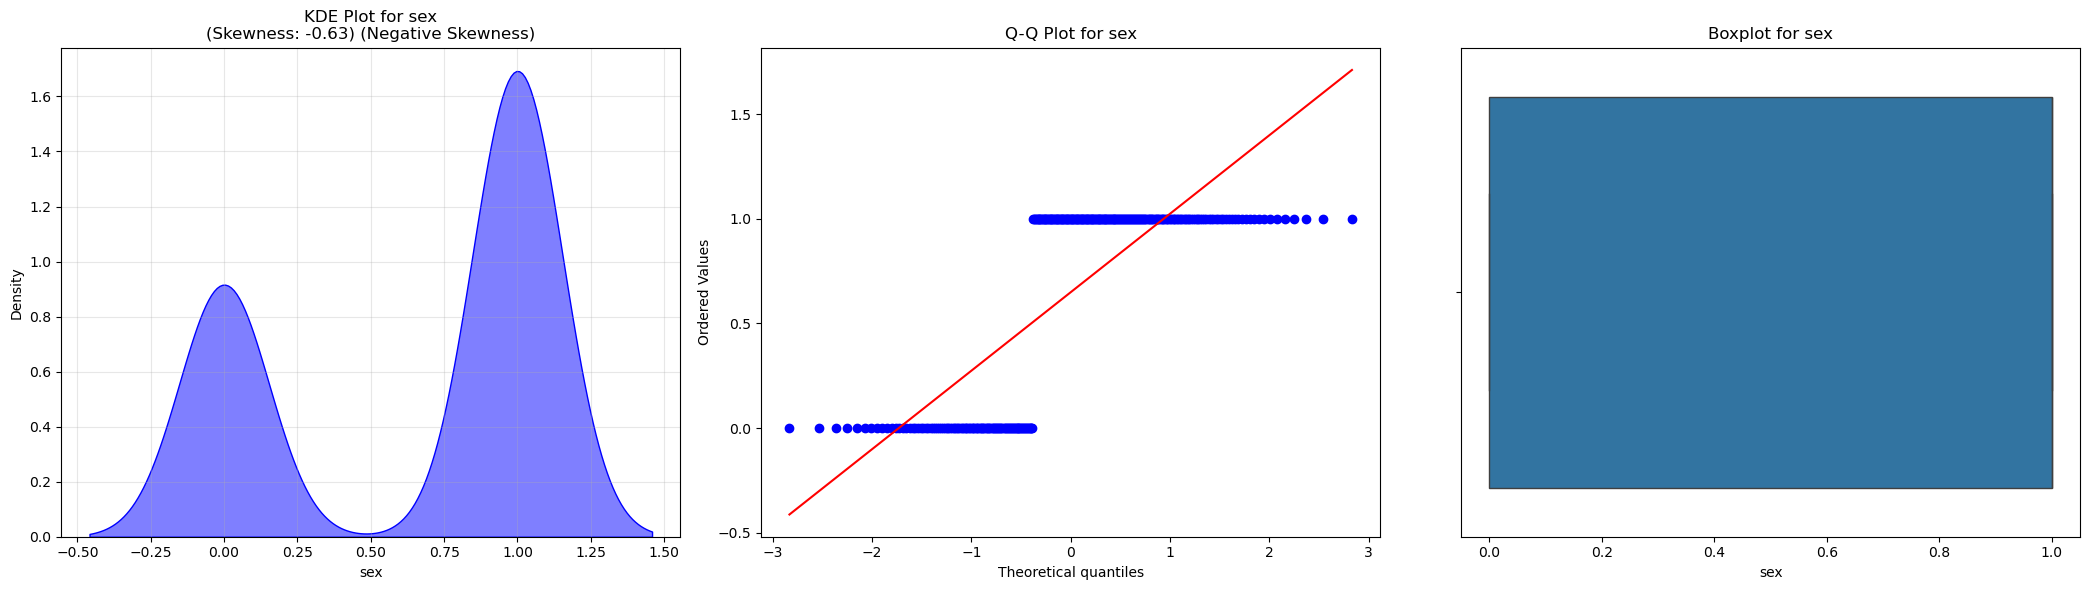

smoking: Skewness = 0.77 (Positive Skewness)


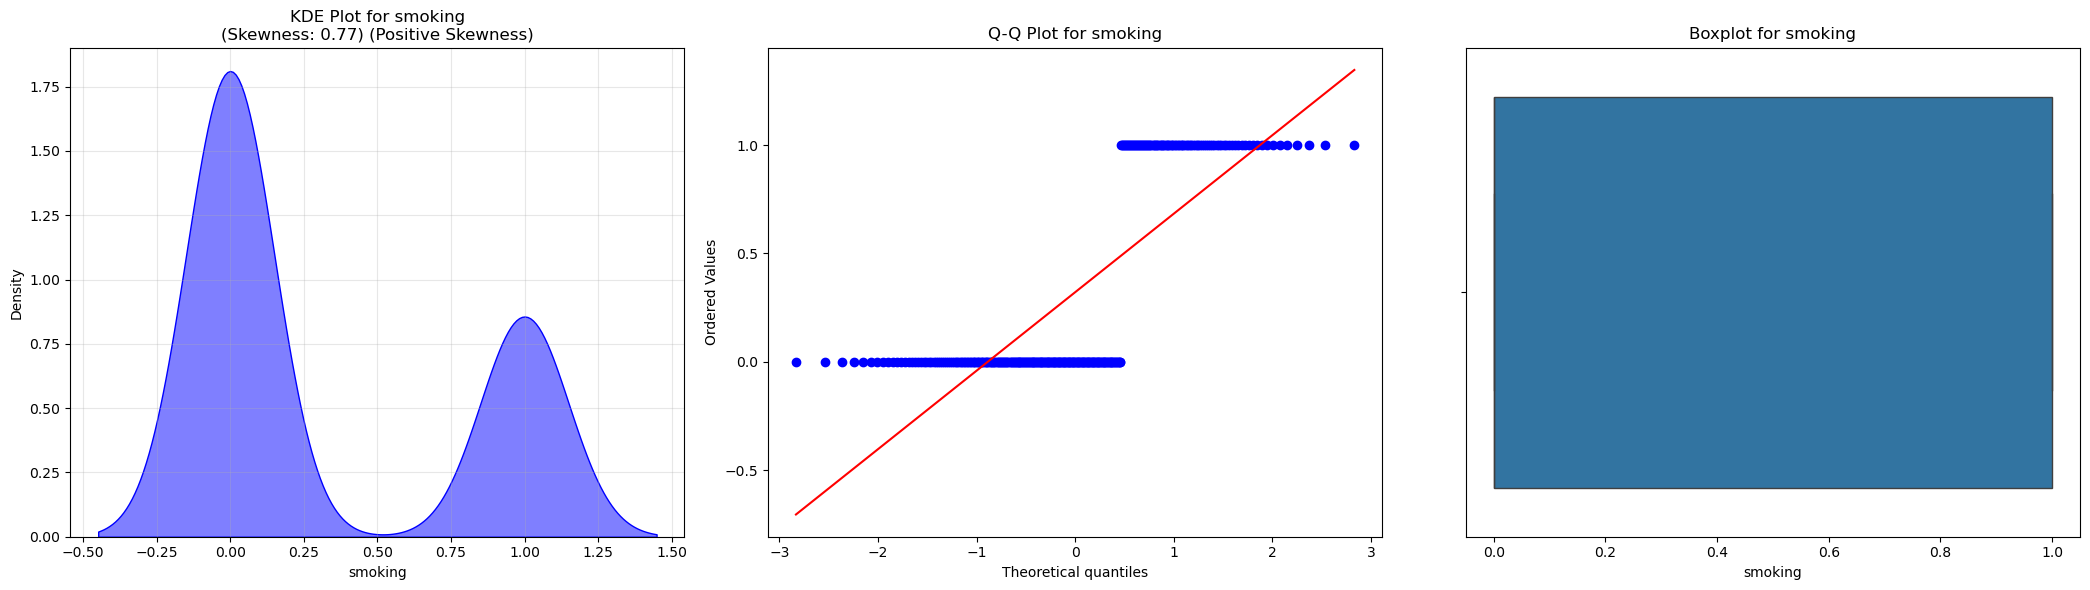

time: Skewness = 0.13 (Positive Skewness)


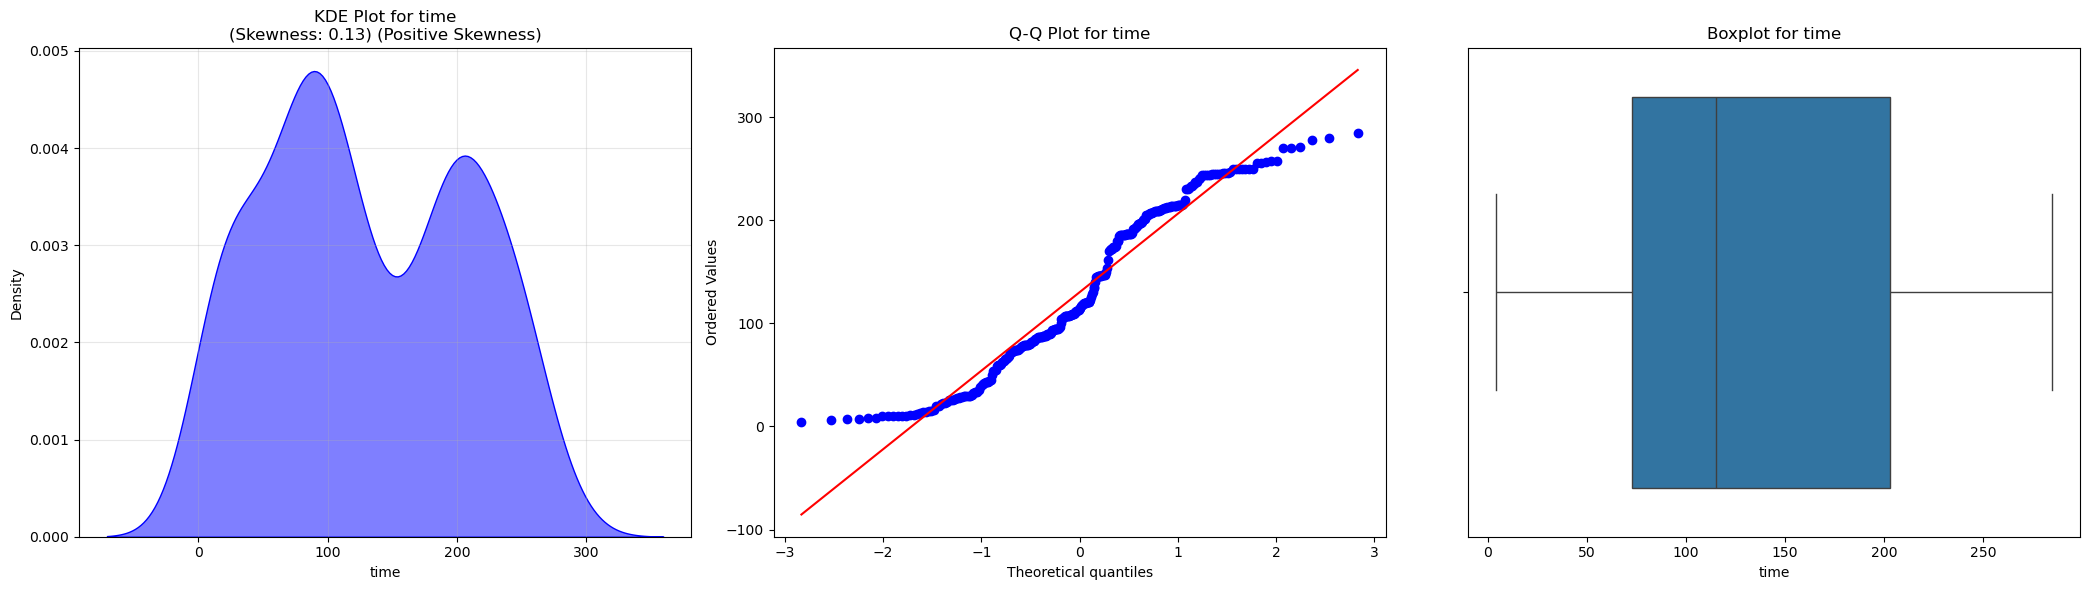

In [175]:
All_plot(X_new)

In [176]:
X_new

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,75.0,0,582.00,0,20.0,1,265000.00,1.90,130,1,0,4
1,55.0,0,1280.25,0,38.0,0,263358.03,1.10,136,1,0,6
2,65.0,0,146.00,0,20.0,0,162000.00,1.30,129,1,1,7
3,50.0,1,111.00,0,20.0,0,210000.00,1.90,137,1,0,7
4,65.0,1,160.00,1,20.0,0,327000.00,2.15,125,0,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61.00,1,38.0,1,155000.00,1.10,143,1,1,270
295,55.0,0,1280.25,0,38.0,0,270000.00,1.20,139,0,0,271
296,45.0,0,1280.25,1,60.0,0,440000.00,0.80,138,0,0,278
297,45.0,0,1280.25,0,38.0,0,140000.00,1.40,140,1,1,280


In [179]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
import pandas as pd

def Advance_column_transformer(df, columns, method='yeo-johnson', standardize=False):
    """
    Applies PowerTransformer to specific columns using ColumnTransformer,
    keeps other columns unchanged.

    Parameters:
    - df: pandas DataFrame
    - columns: list of column names to transform
    - method: 'yeo-johnson' or 'box-cox'
    - standardize: whether to standardize the output

    Returns:
    - transformed_df: full DataFrame with transformed columns
    - lambdas_df: DataFrame with lambdas for transformed columns
    """
    df_copy = df.copy()
    
    # Build ColumnTransformer with a named step
    col_transformer = ColumnTransformer(
        transformers=[
            ('power', PowerTransformer(method=method, standardize=standardize), columns)
        ],
        remainder='passthrough'
    )
    
    # Fit and transform the data
    transformed_array = col_transformer.fit_transform(df_copy)

    # Get the actual fitted PowerTransformer instance from the ColumnTransformer
    fitted_power_transformer = col_transformer.named_transformers_['power']
    
    # Maintain column order: transformed + passthrough
    transformed_columns = columns
    passthrough_columns = [col for col in df.columns if col not in columns]
    all_columns_order = transformed_columns + passthrough_columns

    # Rebuild the DataFrame with proper columns and index
    transformed_df = pd.DataFrame(transformed_array, columns=all_columns_order, index=df.index)

    # Get lambdas
    lambdas_df = pd.DataFrame({'columns': columns, 'lambdas': fitted_power_transformer.lambdas_})

    return transformed_df, lambdas_df


In [181]:
columns = ["age","creatinine_phosphokinase","ejection_fraction","platelets","time","serum_sodium"]

In [183]:
X_new_transform,lambdas_df = Advance_column_transformer(X_new, columns, method='yeo-johnson', standardize=False)

In [185]:
X_new_transform

,age,creatinine_phosphokinase,ejection_fraction,platelets,time,serum_sodium,anaemia,diabetes,high_blood_pressure,serum_creatinine,sex,smoking
0,4.533635,6.793509,5.260806,19267.459004,2.820736,1.435882e+08,0.0,0.0,1.0,1.90,1.0,0.0
1,4.200268,7.695500,7.146801,19175.574054,3.876967,1.728709e+08,0.0,0.0,0.0,1.10,1.0,0.0
2,4.379362,5.249182,5.260806,13195.912026,4.363649,1.390999e+08,0.0,0.0,0.0,1.30,1.0,1.0
3,4.098597,4.949390,5.260806,16111.029662,4.363649,1.781606e+08,1.0,0.0,0.0,1.90,1.0,0.0
4,4.379362,5.349839,5.260806,22648.811337,4.828992,1.222017e+08,1.0,1.0,0.0,2.15,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
294,4.328592,4.303069,7.146801,12755.129147,55.349094,2.125260e+08,0.0,1.0,1.0,1.10,1.0,1.0
295,4.200268,7.695500,7.146801,19546.454910,55.483902,1.891077e+08,0.0,0.0,0.0,1.20,0.0,0.0
296,3.986659,7.695500,8.771821,28456.806410,56.422645,1.835722e+08,0.0,1.0,0.0,0.80,0.0,0.0
297,3.986659,7.695500,7.146801,11794.678718,56.689305,1.947688e+08,0.0,0.0,0.0,1.40,1.0,1.0


In [187]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_new_transform, y, random_state=42, test_size=0.2)

In [189]:
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((239, 12), (60, 12), (239,), (60,))

In [227]:
# # using sampling technique
# # Apply SMOTE to balance the classes
# smote = SMOTE(sampling_strategy='auto', random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [229]:
# Print new class distribution
print(pd.Series(y_train_resampled).value_counts())

DEATH_EVENT
1    168
0    168
Name: count, dtype: int64


In [231]:
# using logistic regression

In [233]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [235]:
model = LogisticRegression()

In [237]:
model.fit(X_train, y_train)

LogisticRegression()

In [247]:
y_test_predict = model.predict(X_test)
y_train_predict = model.predict(X_train)

In [241]:
y_test_predict

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], dtype=int64)

In [249]:
y_train_predict

array([1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
      dtype=int64)

In [251]:
# 8️⃣ Evaluate Model
train_accuracy = accuracy_score(y_train, y_train_predict)
test_accuracy = accuracy_score(y_test, y_test_predict)
print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 0.85
Test Accuracy: 0.73


In [253]:
from sklearn.metrics import confusion_matrix
# Generate confusion matrix
cm = confusion_matrix(y_test, y_test_predict)
cm

array([[33,  2],
       [14, 11]], dtype=int64)

In [259]:
print("\nClassification Train Report:\n", classification_report(y_train, y_train_predict))


Classification Train Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90       168
           1       0.85      0.62      0.72        71

    accuracy                           0.85       239
   macro avg       0.85      0.79      0.81       239
weighted avg       0.85      0.85      0.85       239



In [261]:
print("\nClassification Test Report:\n", classification_report(y_test, y_test_predict))


Classification Test Report:
               precision    recall  f1-score   support

           0       0.70      0.94      0.80        35
           1       0.85      0.44      0.58        25

    accuracy                           0.73        60
   macro avg       0.77      0.69      0.69        60
weighted avg       0.76      0.73      0.71        60



In [263]:
# Cross validation for Regression and Classification
def cross_validation(model, X, y, problem_type='classification', scoring='accuracy', n_splits=10, state_range=50):
    """
    Perform cross-validation across multiple random states and find the best one.

    Parameters:
    - model: scikit-learn model (classifier or regressor)
    - X: features (DataFrame or ndarray)
    - y: labels/target
    - problem_type: 'classification' or 'regression'
    - scoring: scoring metric (e.g., 'accuracy', 'neg_mean_squared_error')
    - n_splits: number of cross-validation folds
    - state_range: number of random states to try (0 to state_range-1)

    Returns:
    - best_random_state: the random_state that gave the highest mean score
    - best_score: corresponding score
    """
    from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
    import numpy as np

    best_score = -np.inf
    best_random_state = None

    for state in range(state_range):
        # Choose cross-validation strategy
        if problem_type == 'classification':
            cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)
        else:
            cv = KFold(n_splits=n_splits, shuffle=True, random_state=state)

        # Cross-validation
        scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
        mean_score = np.mean(scores)
        print(f"Random state {state}: Mean {scoring} = {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_random_state = state

    print(f"\n✅ Best random_state: {best_random_state} with mean {scoring} = {best_score:.4f}")
    return best_random_state, best_score

In [265]:
cross_validation(model, X_new_transform, y, problem_type='classification', scoring='accuracy', n_splits=10, state_range=50)

Random state 0: Mean accuracy = 0.7291
Random state 1: Mean accuracy = 0.7323
Random state 2: Mean accuracy = 0.7328
Random state 3: Mean accuracy = 0.7156
Random state 4: Mean accuracy = 0.7023
Random state 5: Mean accuracy = 0.6923
Random state 6: Mean accuracy = 0.6856
Random state 7: Mean accuracy = 0.7023
Random state 8: Mean accuracy = 0.7556
Random state 9: Mean accuracy = 0.7123


C:\Users\parvez\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random state 10: Mean accuracy = 0.7361
Random state 11: Mean accuracy = 0.7390
Random state 12: Mean accuracy = 0.7194
Random state 13: Mean accuracy = 0.6956
Random state 14: Mean accuracy = 0.7130
Random state 15: Mean accuracy = 0.7056
Random state 16: Mean accuracy = 0.7390
Random state 17: Mean accuracy = 0.6790
Random state 18: Mean accuracy = 0.7395
Random state 19: Mean accuracy = 0.7223
Random state 20: Mean accuracy = 0.7323
Random state 21: Mean accuracy = 0.7323
Random state 22: Mean accuracy = 0.7294
Random state 23: Mean accuracy = 0.6962


C:\Users\parvez\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random state 24: Mean accuracy = 0.7290
Random state 25: Mean accuracy = 0.7693
Random state 26: Mean accuracy = 0.7056
Random state 27: Mean accuracy = 0.7523
Random state 28: Mean accuracy = 0.7490
Random state 29: Mean accuracy = 0.7223
Random state 30: Mean accuracy = 0.6923
Random state 31: Mean accuracy = 0.7056
Random state 32: Mean accuracy = 0.7328
Random state 33: Mean accuracy = 0.7423
Random state 34: Mean accuracy = 0.7197
Random state 35: Mean accuracy = 0.7295
Random state 36: Mean accuracy = 0.7223
Random state 37: Mean accuracy = 0.7490
Random state 38: Mean accuracy = 0.7123
Random state 39: Mean accuracy = 0.7128


C:\Users\parvez\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\parvez\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

Random state 40: Mean accuracy = 0.7329
Random state 41: Mean accuracy = 0.7190


C:\Users\parvez\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random state 42: Mean accuracy = 0.7293
Random state 43: Mean accuracy = 0.7190
Random state 44: Mean accuracy = 0.6890
Random state 45: Mean accuracy = 0.6790
Random state 46: Mean accuracy = 0.7156
Random state 47: Mean accuracy = 0.7356
Random state 48: Mean accuracy = 0.7056
Random state 49: Mean accuracy = 0.7363

✅ Best random_state: 25 with mean accuracy = 0.7693


(25, 0.7693103448275862)

In [269]:
#plot the confusion matrix
def binary_confusion_plot(y_test,y_pred):
    from sklearn.metrics import confusion_matrix
    # Plot confusion matrix using seaborn heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Purples",linewidths=1, linecolor='black',
                xticklabels=['0', '1'], 
                yticklabels=['0', '1'])
    plt.title('Confusion Matrix for Test')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

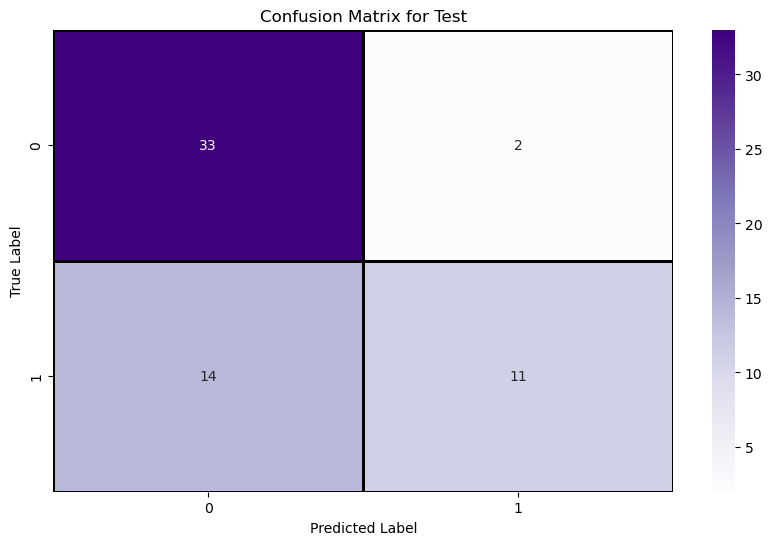

In [271]:
binary_confusion_plot(y_test,y_test_predict)